# **프로젝트: KoChatGPT 업그레이드 하기**

#### 개선 전략: 데이터 정제 + 디코딩 전략 최적화

1. 데이터 정제

기존 KoChatGPT 데이터셋은 ChatGPT API를 통해 수집된 응답으로 구성되어 있으나, 정제되지 않은 상태로 다음과 같은 품질 문제를 포함하고 있었으므로 이를 개선한다.

- 응답 앞뒤에 불필요한 작은따옴표(') 삽입

- 한국어 비율이 낮거나 영어로만 구성된 응답

- 유니코드 대체 문자(\ufffd) 및 인코딩 깨짐

- 너무 짧거나(10자 미만) 너무 긴(800자 초과) 비정상 응답

- RM 데이터에서 최고 순위(ranking=0) 응답이 영어로만 구성된 경우


2. 디코딩 전략 개선 (Decoding Strategy)

기존에는 별도의 디코딩 전략 없이 기본 sampling만 사용했다. 이로 인해 다음과 같은 문제가 발생했다. 이를 개선한다면 답변의 형식이 향상될 것이다.

- 토큰 단위 반복 생성 (닙니다.닙니다.닙니다..., 澳洲는...澳洲는...)

- 프롬프트 길이를 고려하지 않은 max_length 설정으로 응답이 잘리는 현상

- 온도 제어 없이 무작위성이 과도하게 높아지는 경우 발생

```
# 적용한 디코딩 전략 

GENERATION_KWARGS = dict(
    num_beams=4,              # greedy 대비 품질 높은 시퀀스 탐색
    do_sample=True,           # 확률 분포 기반 샘플링 활성화
    temperature=0.7,          # 낮을수록 보수적, 높을수록 무작위 (균형점)
    top_k=50,                 # 확률 상위 50개 토큰 중 샘플링
    top_p=0.92,               # 누적 확률 92% 이내 토큰 중 샘플링
    max_new_tokens=150,       # 프롬프트 길이 무관하게 응답 길이 제어
    repetition_penalty=1.3,   # 이미 생성한 토큰 재생성 확률 억제
    no_repeat_ngram_size=4,   # 4-gram 단위 반복 구간 차단
    eos_token_id=375,         # 줄바꿈 토큰에서 자연스럽게 종료
    early_stopping=True,      # 모든 beam이 eos에 도달하면 즉시 종료
)
```
<br><br/>
#### 파이프라인: SFT -> RM -> PPO -> 모델 평가

- 정성적 평가:

  동일한 질문에 대한 KoGPT-2, SFT, PPO 모델의 답변을 비교한다.

  각 모델의 답변을 보고 문장을 마치는 지점, 동어 반복, 문장 구성, 답변 태도 등의 요소를 통합해 모델 답변 성능이 얼마나 자연스러운지 알 수 있다.

- 정량적 평가:

  * BLEU/ROUGUE
 
  * Reward score

## 1. 환경 및 경로 설정

In [1]:
import sys
import os
import random
import numpy as np
import torch
import gc
from transformers import PreTrainedTokenizerFast  # slow tokenizer 대신 fast tokenizer 고정 사용
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
 
# chatgpt 패키지의 부모 (parent) 디렉토리를 경로에 추가
sys.path.insert(0, os.path.abspath('..'))   # /work
sys.path.insert(0, os.path.abspath('.'))    # /work/chatgpt

In [2]:
# 난수 설정
SEED = 42 # 전역 시드 상수
 
def set_seed(seed: int = SEED):
    """
    모든 난수 생성기를 동일 시드로 고정.
    - Python random, numpy, torch CPU/GPU 전부 고정
    - cudnn deterministic 활성화로 연산 재현성 확보
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
 
set_seed(SEED)
print(f"난수 고정 완료 (seed={SEED})")

난수 고정 완료 (seed=42)


In [3]:
# 데이터 경로
DATA_DIR  = '../KoChatGPT/data_kochatgpt'
PATH_SFT  = os.path.join(DATA_DIR, 'kochatgpt_1_SFT.jsonl')
PATH_RM   = os.path.join(DATA_DIR, 'kochatgpt_2_RM.jsonl')
PATH_PPO  = os.path.join(DATA_DIR, 'kochatgpt_3_PPO.jsonl')
 
# 모델 저장 경로
MODEL_SFT = 'models/output_1_SFT_upgr'
MODEL_RM  = 'models/output_2_RM_upgr'
MODEL_PPO = 'models/output_3_PPO_upgr'
 
# 베이스 모델
BASE_MODEL = 'skt/kogpt2-base-v2'
 
os.makedirs('models', exist_ok=True)
 
print("경로 설정 완료")
print(f"  SFT 데이터: {PATH_SFT}")
print(f"  RM  데이터: {PATH_RM}")
print(f"  PPO 데이터: {PATH_PPO}")

경로 설정 완료
  SFT 데이터: ../KoChatGPT/data_kochatgpt/kochatgpt_1_SFT.jsonl
  RM  데이터: ../KoChatGPT/data_kochatgpt/kochatgpt_2_RM.jsonl
  PPO 데이터: ../KoChatGPT/data_kochatgpt/kochatgpt_3_PPO.jsonl


## 2. 베이스 모델 및 데이터 로드

##### *토크나이저 주의사항:  

AutoTokenizer.from_pretrained('skt/kogpt2-base-v2') 는 GPT2Tokenizer(slow)를 로드함
slow tokenizer는 pre-tokenization 단계에서 한글을 UTF-8 바이트로 분해해 인코딩이 망가짐  

KoGPT-2는 PreTrainedTokenizerFast(Rust 기반)로 사전학습됐으므로 반드시 Fast로 로드해야 함

> 전 파이프라인에서 PreTrainedTokenizerFast 사용

In [4]:
import json
import transformers
from transformers import AutoModelForCausalLM
import pandas as pd
 
print(f"Torch version: {torch.__version__}")
print(f"CUDA version: {torch.version.cuda}")
print(f"transformers version: {transformers.__version__}")
print(f"GPU 사용 가능여부: {torch.cuda.is_available()}")
 
from chatgpt.trainer.strategies import NaiveStrategy

Torch version: 2.7.1+cu118
CUDA version: 11.8
transformers version: 5.3.0
GPU 사용 가능여부: True


In [5]:
def load_tokenizer(path: str = BASE_MODEL) -> PreTrainedTokenizerFast:
    """
    KoGPT-2용 fast tokenizer 로드.
 
    AutoTokenizer 대신 PreTrainedTokenizerFast를 명시적으로 사용하는 이유:
    - AutoTokenizer는 GPT2Tokenizer(Python slow)를 반환함
    - slow tokenizer는 pre-tokenization 시 한글을 UTF-8 바이트로 분해
      -> 인코딩 ID가 바이트 단위(500, 472, 499...)로 쪼개져 디코딩 결과 깨짐
    - PreTrainedTokenizerFast는 KoGPT-2 사전학습 시 사용한 Rust 기반 tokenizer와 동일
      -> 한글 단어 단위 토큰화(9128, 20479...) 정상 작동
    """
    tokenizer = PreTrainedTokenizerFast.from_pretrained(
        path,
        bos_token='</s>',
        eos_token='</s>',
        unk_token='<unk>',  # slow tokenizer에서 '</s>'로 잘못 설정되던 부분 수정
        pad_token='</s>',
        padding_side="right",
        model_max_length=512,
    )
    return tokenizer

In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu" # 장치 설정
 
tokenizer = load_tokenizer(BASE_MODEL)
model = AutoModelForCausalLM.from_pretrained(BASE_MODEL).to(device)
print(f"베이스 모델 로드 완료: {BASE_MODEL}")
print(f"토크나이저 클래스: {type(tokenizer).__name__}")  # PreTrainedTokenizerFast 확인용

tokenizer.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/513M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
GPT2LMHeadModel LOAD REPORT from: skt/kogpt2-base-v2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


베이스 모델 로드 완료: skt/kogpt2-base-v2
토크나이저 클래스: TokenizersBackend


In [7]:
# 토크나이저 인코딩 <-> 디코딩 왕복 테스트 (한글 정상 처리 확인용)
test_text = "불고기용 고기 한우에요?"
encoded = tokenizer.encode(test_text, return_tensors='pt')
decoded = tokenizer.decode(encoded[0], skip_special_tokens=True)
print(f"[토크나이저 왕복 테스트]")
print(f"  원문:   {test_text}")
print(f"  encode: {encoded}")
print(f"  decode: {decoded}")
assert decoded == test_text, "토크나이저 왕복 테스트 실패! 한글 처리 확인 필요"
print("  테스트 통과")

[토크나이저 왕복 테스트]
  원문:   불고기용 고기 한우에요?
  encode: tensor([[ 9128, 20479,  8091, 22311,  9036, 30902,  8084,   406]])
  decode: 불고기용 고기 한우에요?
  테스트 통과


In [8]:
# 데이터 로드 및 기본 정보 확인
with open(PATH_SFT, "r", encoding='utf-8-sig') as f:
    sft_raw = json.load(f)
with open(PATH_RM, "r", encoding='utf-8-sig') as f:
    rm_raw = json.load(f)
with open(PATH_PPO, "r", encoding='utf-8-sig') as f:
    ppo_raw = json.load(f)
 
print(f"SFT 데이터 수: {len(sft_raw)}")
print(f"RM  데이터 수: {len(rm_raw)}")
print(f"PPO 데이터 수: {len(ppo_raw)}")
print(f"\nSFT 샘플:\n{sft_raw[0]}")

model.safetensors:   0%|          | 0.00/513M [00:00<?, ?B/s]

SFT 데이터 수: 12000
RM  데이터 수: 10220
PPO 데이터 수: 12000

SFT 샘플:
{'prompt': '불고기용 고기 한우에요?', 'completion': "'저는 인공지능 챗봇이며, 직접적으로 식품에 관한 정보를 가지고 있지 않습니다. 하지만 일반적으로 불고기용 고기는 한우, 쇠고기, 돼지고기 등 다양한 종류의 고기를 사용합니다. 하지만 한우는 대표적인 고급 육류로 알려져 있기 때문에, 한우를 사용하는 경우도 많습니다. 알러지나 개별 건강 상태에 따라 다를 수 있으니 충분한 정보 수집 후에 선택해 주시기 바랍니다.", 'tokens': 193}


## 3. 데이터 정제

정제 전후 샘플 수와 품질을 단계별로 확인한다.

In [9]:
import re
 
def is_valid_korean(text, min_korean_ratio=0.3):
    """
    한국어 비율이 기준 이상인지 확인한다.
    - 한글 유니코드: AC00~D7A3 (완성형), 1100~11FF (자모)
    - min_korean_ratio: 공백 제외 전체 글자 중 한글 최소 비율
    """
    if not text or len(text.strip()) == 0:
        return False
    korean_chars = re.findall(r'[\uAC00-\uD7A3\u1100-\u11FF]', text)
    ratio = len(korean_chars) / max(len(text.replace(' ', '')), 1)
    return ratio >= min_korean_ratio
 
def clean_text(text):
    """
    텍스트를 정제한다.
    - 원본 데이터에 ChatGPT API 응답 앞뒤로 작은따옴표가 붙는 경우 많아 제거
    - 연속 공백을 단일 공백으로 정규화
    - 앞뒤 공백 제거
    """
    text = text.strip()
    if text.startswith("'") and text.endswith("'"):
        text = text[1:-1]
    elif text.startswith("'"):
        text = text[1:]
    text = re.sub(r' +', ' ', text)
    return text.strip()
 
def is_too_short(text, min_len=5):
    """텍스트가 min_len 글자 미만이면 True"""
    return len(text.strip()) < min_len
 
def is_too_long(text, max_len=800):
    """텍스트가 max_len 글자 초과이면 True"""
    return len(text.strip()) > max_len
 
def has_broken_encoding(text):
    """
    인코딩 깨짐 여부를 확인한다.
    - U+FFFD: 유니코드 대체 문자 (디코딩 실패 시 자동 삽입)
    - '???': 깨진 한글이 변환된 패턴
    """
    return '\ufffd' in text or '???' in text

### 3-1. SFT 데이터 정제

- 데이터 형태: Prompt(질문) + Completion(정답 답변) 쌍

- 모델은 정답 답변을 글자 단위로 예측하며 그대로 따라 하도록 학습

- 답변에 노이즈가 많으면 모델이 그대로 외울 수 있으므로 구두점 제거 등 정답 데이터를 _깨끗하게_ 정제하는 것이 중요

In [10]:
print("SFT 데이터 정제 시작")
print(f"정제 전 샘플 수: {len(sft_raw)}")
 
sft_cleaned = []
sft_removed = {'short': 0, 'long': 0, 'not_korean': 0, 'broken': 0}
 
for item in sft_raw:
    prompt     = clean_text(item.get('prompt', ''))
    completion = clean_text(item.get('completion', ''))
 
    if is_too_short(completion, min_len=10):
        sft_removed['short'] += 1
        continue
    if is_too_long(completion, max_len=800):
        sft_removed['long'] += 1
        continue
    if not is_valid_korean(completion, min_korean_ratio=0.2):
        sft_removed['not_korean'] += 1
        continue
    if has_broken_encoding(completion):
        sft_removed['broken'] += 1
        continue
 
    sft_cleaned.append({'prompt': prompt, 'completion': completion})
 
print(f"정제 후 샘플 수: {len(sft_cleaned)}")
print(f"제거 현황: {sft_removed}")
print(f"제거율: {(len(sft_raw) - len(sft_cleaned)) / len(sft_raw) * 100:.1f}%")

SFT 데이터 정제 시작
정제 전 샘플 수: 12000
정제 후 샘플 수: 11436
제거 현황: {'short': 189, 'long': 27, 'not_korean': 348, 'broken': 0}
제거율: 4.7%


In [11]:
# 정제 전후 샘플 비교
print("정제 전 샘플:")
print(f"  prompt:     {sft_raw[0]['prompt']}")
print(f"  completion: {sft_raw[0]['completion'][:100]}...")
print()
print("정제 후 샘플:")
print(f"  prompt:     {sft_cleaned[0]['prompt']}")
print(f"  completion: {sft_cleaned[0]['completion'][:100]}...")

정제 전 샘플:
  prompt:     불고기용 고기 한우에요?
  completion: '저는 인공지능 챗봇이며, 직접적으로 식품에 관한 정보를 가지고 있지 않습니다. 하지만 일반적으로 불고기용 고기는 한우, 쇠고기, 돼지고기 등 다양한 종류의 고기를 사용합니다. 하...

정제 후 샘플:
  prompt:     불고기용 고기 한우에요?
  completion: 저는 인공지능 챗봇이며, 직접적으로 식품에 관한 정보를 가지고 있지 않습니다. 하지만 일반적으로 불고기용 고기는 한우, 쇠고기, 돼지고기 등 다양한 종류의 고기를 사용합니다. 하지...


In [12]:
# completion 길이 분포 비교
before_lens = [len(item['completion']) for item in sft_raw]
after_lens  = [len(item['completion']) for item in sft_cleaned]
 
print("completion 길이 분포 (정제 전)")
print(f"  평균: {np.mean(before_lens):.1f}  중앙값: {np.median(before_lens):.1f}  최대: {max(before_lens)}")
print("completion 길이 분포 (정제 후)")
print(f"  평균: {np.mean(after_lens):.1f}  중앙값: {np.median(after_lens):.1f}  최대: {max(after_lens)}")

completion 길이 분포 (정제 전)
  평균: 144.1  중앙값: 118.0  최대: 1553
completion 길이 분포 (정제 후)
  평균: 143.9  중앙값: 118.0  최대: 790


### 3-2. RM 데이터 정제

- 데이터 형태: 하나의 Prompt에 대해 모델이 내놓은 3가지 답변(completion_0, 1, 2)과 그들 사이의 순위(Ranking)

- chosen(좋은 답변)과 rejected(나쁜 답변)를 쌍으로 묶어, 판사 모델이 좋은 답변에는 높은 점수(Reward)를, 나쁜 답변에는 낮은 점수를 주도록 훈련

- 사람이 선호하는 답변의 특성을 수치화된 점수로 변환하는 기준을 세우는 단계이므로 여기에서 순위 데이터 부족으로 판사 모델이 편향되지 않도록 주의

In [13]:
print("RM 데이터 정제 시작")
print(f"정제 전 샘플 수: {len(rm_raw)}")
 
rm_cleaned = []
rm_removed = {'short': 0, 'not_korean': 0, 'broken': 0}
 
for item in rm_raw:
    completions = [
        clean_text(item.get('completion_0', '')),
        clean_text(item.get('completion_1', '')),
        clean_text(item.get('completion_2', '')),
    ]
    ranking = item.get('ranking', [0, 1, 2])
 
    # 3개 completion 중 하나라도 필터에 걸리면 전체 샘플 제외
    skip = False
    for comp in completions:
        if is_too_short(comp, min_len=5): # 최소 길이 제한
            rm_removed['short'] += 1
            skip = True
            break
        if has_broken_encoding(comp): # 깨진 문자 제거
            rm_removed['broken'] += 1
            skip = True
            break
    if skip:
        continue
 
    # 가장 좋은 ranking(0)인 completion이 한국어가 아니면 제외
    best_idx = ranking.index(0)
    if not is_valid_korean(completions[best_idx], min_korean_ratio=0.2):
        rm_removed['not_korean'] += 1
        continue
 
    rm_cleaned.append({
        'prompt':       clean_text(item['prompt']),
        'completion_0': completions[0],
        'completion_1': completions[1],
        'completion_2': completions[2],
        'ranking':      ranking,
    })
 
print(f"정제 후 샘플 수: {len(rm_cleaned)}")
print(f"제거 현황: {rm_removed}")
print(f"제거율: {(len(rm_raw) - len(rm_cleaned)) / len(rm_raw) * 100:.1f}%")

RM 데이터 정제 시작
정제 전 샘플 수: 10220
정제 후 샘플 수: 9121
제거 현황: {'short': 382, 'not_korean': 716, 'broken': 1}
제거율: 10.8%


In [14]:
# RM 정제 후 샘플 확인
sample = rm_cleaned[0]
print("RM 정제 후 샘플:")
print(f"  prompt:       {sample['prompt']}")
print(f"  completion_0: {sample['completion_0'][:80]}...")
print(f"  completion_1: {sample['completion_1'][:80]}...")
print(f"  completion_2: {sample['completion_2'][:80]}...")
print(f"  ranking:      {sample['ranking']}")

RM 정제 후 샘플:
  prompt:       번디는 자신이 탐정잡지, 범죄소설 그리고 성범죄 관련 실제 범죄 다큐멘터리들을 탐독했다고 누구에게 말했나?
  completion_0: Allow me to answer your question. I know that you are curious about me....
  completion_1: 번디는 다양한 인터뷰자들과 뉴스홍보 담당자들과의 면담 때 밝혔다....
  completion_2: 라이언에게 말했다....
  ranking:      [2, 1, 0]


### 3-3. PPO 데이터 정제

- 데이터 형태: 답변은 모델이 실시간으로 생성하므로 오직 Prompt(질문)만 필요

- 모델이 정답을 외우는 게 아니라 어떻게 해야 더 높은 점수(인간의 선호도)를 받을지 고민하며 지능을 고도화

In [15]:
print("PPO 데이터 정제 시작")
print(f"정제 전 샘플 수: {len(ppo_raw)}")
 
ppo_cleaned = []
for item in ppo_raw:
    prompt = clean_text(item.get('prompt', ''))
    if is_too_short(prompt, min_len=3):
        continue
    if has_broken_encoding(prompt):
        continue
    ppo_cleaned.append({'prompt': prompt})
 
print(f"정제 후 샘플 수: {len(ppo_cleaned)}")
print(f"제거율: {(len(ppo_raw) - len(ppo_cleaned)) / len(ppo_raw) * 100:.1f}%")
print(f"샘플 확인: {ppo_cleaned[0]}")

PPO 데이터 정제 시작
정제 전 샘플 수: 12000
정제 후 샘플 수: 11970
제거율: 0.2%
샘플 확인: {'prompt': '번디는 자신이 탐정잡지, 범죄소설 그리고 성범죄 관련 실제 범죄 다큐멘터리들을 탐독했다고 누구에게 말했나?'}


## 4. Supervised Fine-Tuning 학습 (SFT)

In [16]:
from typing import Optional, Dict, Sequence
from torch.utils.data import Dataset
from dataclasses import dataclass
import logging
import copy

In [17]:
class SFT_dataset(Dataset):
    """
    SFT용 데이터셋.
    - Instruction 부분 label -100 마스킹 → CrossEntropyLoss에서 자동 제외
    - Response 부분만 학습 대상
    - data_list: 정제된 [{'prompt': ..., 'completion': ...}] 리스트 직접 수신
    """
    def __init__(self, data_list: list, tokenizer: PreTrainedTokenizerFast):
        super(SFT_dataset, self).__init__()
        logging.warning("Loading SFT data...")
 
        prompt_template = "### Instruction(명령어):\n{prompt}\n\n### Response(응답):"
 
        sources  = [prompt_template.format_map(ex) for ex in data_list]
        targets  = [f"{ex['completion']}{tokenizer.eos_token}" for ex in data_list]
        examples = [s + t for s, t in zip(sources, targets)]
 
        sources_tokenized  = self._tokenize_fn(sources,  tokenizer)
        examples_tokenized = self._tokenize_fn(examples, tokenizer)
 
        input_ids = examples_tokenized["input_ids"]
        labels    = copy.deepcopy(input_ids)
 
        # Instruction 길이만큼 앞부분 -100 마스킹
        for label, src_len in zip(labels, sources_tokenized["input_ids_lens"]):
            label[:src_len] = -100
 
        self.input_ids = input_ids
        self.labels    = labels
        logging.warning(f"Loading SFT data done: {len(self.labels)}")
 
    def _tokenize_fn(self, strings: Sequence[str],
                     tokenizer: PreTrainedTokenizerFast) -> Dict:
        """문자열 리스트를 토크나이징하고 유효 토큰 수(패딩 제외) 반환"""
        tokenized_list = [
            tokenizer(
                text,
                return_tensors="pt",
                padding="longest",
                max_length=tokenizer.model_max_length,
                truncation=True,
            )
            for text in strings
        ]
        input_ids      = [t.input_ids[0] for t in tokenized_list]
        input_ids_lens = [
            t.input_ids.ne(tokenizer.pad_token_id).sum().item()
            for t in tokenized_list
        ]
        return dict(input_ids=input_ids, labels=input_ids,
                    input_ids_lens=input_ids_lens, labels_lens=input_ids_lens)
 
    def __len__(self):
        return len(self.input_ids)
 
    def __getitem__(self, i) -> Dict[str, torch.Tensor]:
        return dict(input_ids=self.input_ids[i], labels=self.labels[i])

In [18]:
@dataclass
class DataCollatorForSupervisedDataset(object):
    """
    배치 내 시퀀스 길이를 맞추는 DataCollator.
    - input_ids 패딩값: pad_token_id
    - labels 패딩값: -100 (ignore_index 기본값, loss 자동 제외)
    """
    tokenizer: PreTrainedTokenizerFast
 
    def __call__(self, instances: Sequence[Dict]) -> Dict[str, torch.Tensor]:
        input_ids, labels = tuple(
            [inst[key] for inst in instances]
            for key in ("input_ids", "labels")
        )
        input_ids = torch.nn.utils.rnn.pad_sequence(
            input_ids, batch_first=True,
            padding_value=self.tokenizer.pad_token_id
        )
        labels = torch.nn.utils.rnn.pad_sequence(
            labels, batch_first=True, padding_value=-100
        )
        return dict(
            input_ids=input_ids,
            labels=labels,
            attention_mask=input_ids.ne(self.tokenizer.pad_token_id),
        )

In [19]:
set_seed(SEED)
 
tokenizer = load_tokenizer(BASE_MODEL)
model = AutoModelForCausalLM.from_pretrained(BASE_MODEL)
 
train_dataset = SFT_dataset(data_list=sft_cleaned, tokenizer=tokenizer)
data_collator = DataCollatorForSupervisedDataset(tokenizer=tokenizer)
 
print(f"SFT 데이터셋 구성 완료: {len(train_dataset)}개")
print(f"input 샘플(앞 10 토큰): {train_dataset.input_ids[0][:10]}")
print(f"label 샘플(앞 10 토큰): {train_dataset.labels[0][:10]}")

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
GPT2LMHeadModel LOAD REPORT from: skt/kogpt2-base-v2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


SFT 데이터셋 구성 완료: 11436개
input 샘플(앞 10 토큰): tensor([  739,   378,   378,   378, 14659, 13394, 37091, 10651,   383, 25841])
label 샘플(앞 10 토큰): tensor([-100, -100, -100, -100, -100, -100, -100, -100, -100, -100])


In [20]:
# label 전체 출력해서 -100이 끝나는 지점 확인
label = train_dataset.labels[0]

# -100이 아닌 첫 번째 인덱스 찾기
first_real = (label != -100).nonzero(as_tuple=True)[0][0].item()
print(f"-100 마스킹 끝나는 위치: {first_real}")
print(f"그 이후 토큰 (Response 시작): {label[first_real:first_real+10]}")
print(f"디코딩: {tokenizer.decode(label[label != -100][:20])}")

-100 마스킹 끝나는 위치: 32
그 이후 토큰 (Response 시작): tensor([37767, 13753,  8263,  7166,   739,  8352,  7659,  9594, 25585, 13600])
디코딩: 저는 인공지능 챗봇이며, 직접적으로 식품에 관한 정보를 가지고 있지 않습니다. 하지만 일반적으로 불


In [21]:
# 학습 전 메모리 정리
gc.collect()
torch.cuda.empty_cache()
print(f"SFT 학습 전 메모리 정리 완료")
print(f"  allocated: {torch.cuda.memory_allocated()/1024**3:.2f} GB")
print(f"  reserved:  {torch.cuda.memory_reserved()/1024**3:.2f} GB")

SFT 학습 전 메모리 정리 완료
  allocated: 0.00 GB
  reserved:  0.00 GB


In [22]:
%%time
# SFT 학습
# num_train_epochs: 데이터 정제 후 2~3 권장. 1은 빠른 확인용.
training_args = transformers.TrainingArguments(
    output_dir=MODEL_SFT,
    num_train_epochs=3,            # 권장: 2~3
    per_device_train_batch_size=2, # OOM 에러 방지: 8 -> 2
    per_device_eval_batch_size=2,  # 8 -> 2
    gradient_accumulation_steps=4, # 유효 배치 = 2*4 = 8 유지
    warmup_steps=50,               # 전체 스텝의 1~3% 권장
    learning_rate=2e-5,
    weight_decay=0.01,
    fp16=True,
    logging_steps=100,
    save_strategy="epoch",
    seed=SEED,
)
trainer = transformers.Trainer(
    model=model,
    args=training_args,
    data_collator=data_collator,
    train_dataset=train_dataset,
)
trainer.train()
model.save_pretrained(MODEL_SFT)
# 토크나이저도 반드시 함께 저장 (이후 로드 시 fast tokenizer 유지 보장)
tokenizer.save_pretrained(MODEL_SFT)
print(f"SFT 모델 및 토크나이저 저장 완료: {MODEL_SFT}")

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Step,Training Loss
100,3.336861
200,2.905944
300,2.865854
400,2.904511
500,2.826419
600,2.821620
700,2.796917
800,2.754026
900,2.799623
1000,2.768550


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

SFT 모델 및 토크나이저 저장 완료: models/output_1_SFT_upgr
CPU times: user 17min 33s, sys: 10.9 s, total: 17min 43s
Wall time: 17min 45s


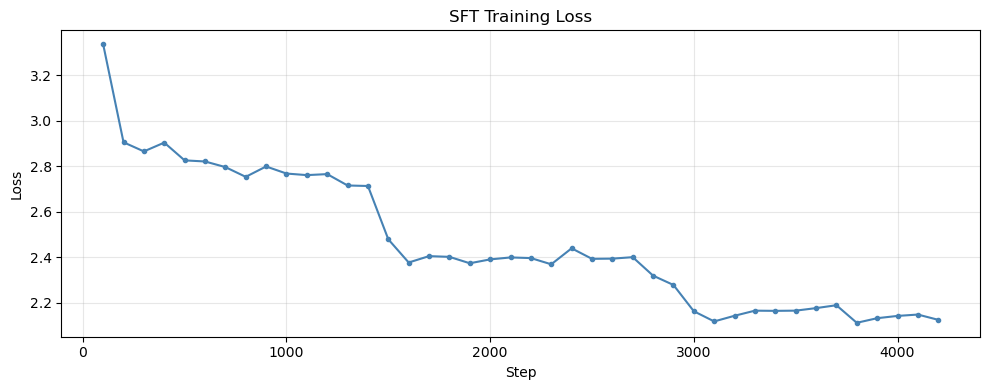

초기 loss: 3.3369  최종 loss: 2.1255


In [23]:
# 학습 곡선 시각화
log_history = trainer.state.log_history # trainer.state.log_history에 학습 로그가 저장돼 있음

steps  = [x['step'] for x in log_history if 'loss' in x]
losses = [x['loss'] for x in log_history if 'loss' in x]

plt.figure(figsize=(10, 4))
plt.plot(steps, losses, marker='o', markersize=3, linewidth=1.5, color='steelblue')
plt.title('SFT Training Loss')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('sft_loss_curve.png', dpi=150)
plt.show()
print(f"초기 loss: {losses[0]:.4f}  최종 loss: {losses[-1]:.4f}")

**SFT 학습 곡선 분석**

- loss가 `3.3`대에서 시작해 4200 스텝 (3에폭)을 거친 후 점차 우하향하며 `2.1`대로 감소했다.

- 3000번째 스텝 이후에는 감소폭이 현저히 줄어든다. 이는 현재 주어진 데이터셋으로 할 수 있는 학습을 거의 다 한 상태라고 해석된다.

In [24]:
# SFT 학습 직후 추론
# 학습된 모델과 fast tokenizer로 추론
infer_tokenizer = PreTrainedTokenizerFast.from_pretrained(MODEL_SFT)
infer_model = model  # 방금 학습한 모델 그대로 사용
infer_model.eval()

PROMPT_DICT = {
    "prompt_input": "### Instruction(명령어):\n{prompt}\n\n### Response(응답):"
}

test_prompts = [
    '불고기용 고기 한우에요?',
    '오늘 미세먼지 어때?',
    '시카고 오헤어 국제공항은 어디에 있어?',
]

for p in test_prompts:
    prompt = PROMPT_DICT['prompt_input'].format_map({'prompt': p})
    input_ids = infer_tokenizer.encode(prompt, return_tensors='pt').to(device)

    with torch.no_grad():
        output_ids = infer_model.generate(
            input_ids,
            max_new_tokens=100,
            do_sample=True,
            temperature=0.7,
            top_k=50,
            top_p=0.92,
            repetition_penalty=1.3,
            no_repeat_ngram_size=4,
            eos_token_id=infer_tokenizer.eos_token_id,
        )

    full_text = infer_tokenizer.decode(output_ids[0], skip_special_tokens=True,
                                        clean_up_tokenization_spaces=True)
    response = full_text[len(prompt):].strip()
    print(f"Q: {p}")
    print(f"A: {response}")
    print()

Q: 불고기용 고기 한우에요?
A: 저는 인공지능 언어모델로써 답변을 제공합니다. 따라서 불고기의 종류와 양에 대한 정보는 제공할 수 없습니다. 하지만 일반적으로 쇠고기는 육류보다 지방이 적고 고기에 함유된 칼슘과 마그네슘, 철분이 많아서 건강에 좋다고 알려져 있습니다. 또한 콜레스테롤을 낮추기 위해 혈당을 조절하여 건강을 유지하는 데에도 도움이 된다는 연구 결과가 있습니다.

Q: 오늘 미세먼지 어때?
A: 미세 먼지는 보통 야외 활동이나 운동 시 발생하는 오염물질입니다. 일부 실외 활동에서는 마스크를 착용하거나 실내 공기 질을 유지하는 것이 좋습니다. 또한, 집안이나 공터에서 사용하는 가전제품 및 청소기 등의 필터류도 도움이 됩니다. 따라서 외출 전에는 반드시 마스크를 챙기고, 올바른 사용을 통해 건강을 유지하시는 것이 중요합니다.

Q: 시카고 오헤어 국제공항은 어디에 있어?
A: 저는 인공지능 어시스턴트이기 때문에 시카고에 대한 정보를 알 수 없습니다. 하지만 시카고에서 활동하는 많은 인프라는 다양한 도시에서 운영되고 있습니다.



**중간 추론 점검**

- SFT 데이터셋에 포함된 거절 응답이나 일반적인 챗봇의 페르소나를 잘 학습했다. 할루시네이션 현상을 일으키기 보다는 모른다는 건 모른다고 하는 편이 나으므로 안전성 면에서는 긍정적이다.

  * 저는 인공지능 언어모델로써 답변을 제공합니다.
 
  * 시카고에 대한 정보를 알 수 없습니다.

- 사실 관계를 잘 파악하지 못하고 있다. KoGPT-2(125M) 모델 규모로 인해 발생하는 문제로 보인다. 또한 실시간 데이터를 불러올 수 없는 모델의 한계를 여실히 드러낸다.

  * 쇠고기는 육류보다 지방이 적고
 
  * 오늘 미세먼지 어때? -> 미세 먼지는 보통 야외 활동이나 운동 시 발생하는 오염물질입니다. (실시간 데이터가 없어 일반적인 설명만 가능)

In [25]:
# 메모리 해제
del model, train_dataset, data_collator, trainer
torch.cuda.empty_cache()
print("SFT 메모리 해제 완료")

SFT 메모리 해제 완료


## 5. Reward Model 학습 (RM)

In [26]:
from chatgpt.dataset import RewardDataset
from chatgpt.models.base import RewardModel
from chatgpt.trainer.strategies import NaiveStrategy
from chatgpt.trainer.rm import RewardModelTrainer
from transformers.models.gpt2.configuration_gpt2 import GPT2Config
from transformers.models.gpt2.modeling_gpt2 import GPT2Model
import torch.nn as nn

In [27]:
class GPTRM_custom(RewardModel):
    """
    KoGPT-2 기반 커스텀 Reward Model.
    - GPT2Model 위에 scalar 출력용 value_head(Linear(n_embd, 1)) 추가
    - pretrained 경로 또는 GPT2Config 중 하나로 초기화
    """
    def __init__(self,
                 pretrained: Optional[str] = None,
                 config: Optional[GPT2Config] = None,
                 checkpoint: bool = False,
                 lora_rank: int = 0,
                 lora_train_bias: str = 'none',
                 tokenizer=None) -> None:
        if pretrained is not None:
            model = GPT2Model.from_pretrained(pretrained)
            model.resize_token_embeddings(len(tokenizer))
        elif config is not None:
            model = GPT2Model(config)
        else:
            model = GPT2Model(GPT2Config())
 
        if checkpoint:
            model.gradient_checkpointing_enable()
 
        value_head = nn.Linear(model.config.n_embd, 1)
        super().__init__(model, value_head, lora_rank, lora_train_bias)
 
        if pretrained is not None:
            self.model      = model
            self.pretrained = pretrained
 
    def save_pretrained(self, dir):
        """모델 가중치를 지정 경로에 저장"""
        if self.pretrained is not None:
            self.model.save_pretrained(dir)

In [28]:
set_seed(SEED)
 
# SFT 저장 경로에서 토크나이저 로드 (fast tokenizer가 저장돼 있음)
tokenizer = load_tokenizer(MODEL_SFT)
model = AutoModelForCausalLM.from_pretrained(BASE_MODEL)
 
with NaiveStrategy().model_init_context():
    model = GPTRM_custom(
        pretrained=BASE_MODEL, lora_rank=0, tokenizer=tokenizer
    ).cuda()

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
GPT2LMHeadModel LOAD REPORT from: skt/kogpt2-base-v2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2Model LOAD REPORT from: skt/kogpt2-base-v2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 
lm_head.weight                          | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [29]:
# 정제된 RM 데이터로 chosen/rejected 쌍 구성
total_data_ranking2chosen = []
 
for tmp in rm_cleaned:
    for i, j in [(0, 1), (0, 2), (1, 2)]:
        data  = {'prompt': tmp['prompt']}
        key_i = f'completion_{i}'
        key_j = f'completion_{j}'
        if tmp['ranking'][i] < tmp['ranking'][j]:
            data['chosen']   = tmp[key_i]
            data['rejected'] = tmp[key_j]
        else:
            data['chosen']   = tmp[key_j]
            data['rejected'] = tmp[key_i]
        total_data_ranking2chosen.append(data)
 
print(f"정제 전 RM: {len(rm_raw)}개 → 정제 후: {len(rm_cleaned)}개")
print(f"chosen/rejected 쌍: {len(total_data_ranking2chosen)}개")
print(f"샘플: {total_data_ranking2chosen[0]}")

정제 전 RM: 10220개 → 정제 후: 9121개
chosen/rejected 쌍: 27363개
샘플: {'prompt': '번디는 자신이 탐정잡지, 범죄소설 그리고 성범죄 관련 실제 범죄 다큐멘터리들을 탐독했다고 누구에게 말했나?', 'chosen': '번디는 다양한 인터뷰자들과 뉴스홍보 담당자들과의 면담 때 밝혔다.', 'rejected': 'Allow me to answer your question. I know that you are curious about me.'}


In [30]:
# 시드 고정 후 셔플 및 분할
random.seed(SEED)
random.shuffle(total_data_ranking2chosen)
 
train_data = total_data_ranking2chosen[:1000]
eval_data  = total_data_ranking2chosen[1000:1200]
 
print(f"train: {len(train_data)}개 / eval: {len(eval_data)}개")
 
train_dataset = RewardDataset(train_data, tokenizer, 512)
eval_dataset  = RewardDataset(eval_data,  tokenizer, 512)

train: 1000개 / eval: 200개


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

In [31]:
# 학습 전 메모리 정리
gc.collect()
torch.cuda.empty_cache()
print(f"RM 학습 전 메모리 정리 완료")
print(f"  allocated: {torch.cuda.memory_allocated()/1024**3:.2f} GB")
print(f"  reserved:  {torch.cuda.memory_reserved()/1024**3:.2f} GB")

RM 학습 전 메모리 정리 완료
  allocated: 1.10 GB
  reserved:  1.33 GB


In [32]:
%%time
# RM 학습
# max_epochs: 1~2 권장
trainer = RewardModelTrainer(
    model=model,
    strategy=NaiveStrategy(),
    optim=torch.optim.Adam(model.parameters(), lr=5e-5),
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    batch_size=4,
    max_epochs=1,
)
trainer.fit(use_lora=0)
model.save_pretrained(MODEL_RM)
print(f"RM 모델 저장 완료: {MODEL_RM}")

Train epoch: 100%|██████████| 1/1 [03:58<00:00, 238.48s/it]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

RM 모델 저장 완료: models/output_2_RM_upgr
CPU times: user 3min 24s, sys: 35.1 s, total: 3min 59s
Wall time: 3min 59s


**RM 학습 로그 분석**

- RM 학습은 정답을 맞히기 위함이 아니라 선호도를 익히기 위함이다. 그러므로 에폭을 `1`로 설정해 모델이 문장의 너무 세세한 부분보다 전체적인 의미를 파악할 수 있도록 했다.

- 학습 로그를 loss가 `0.6`에서 시작해 `0.2` ~ `0.4`대까지 낮아지는 추세를 보인다. RM 모델이 인간의 선호도를 이해해가고 있다는 신호이다.

- 중간에 loss가 튀는 구간이 있는데, 다음과 같이 추정한다.

  * 초반 구간 (Loss 1.54): 학습 과정에서 나타나는 자연스러운 현상으로 볼 수 있다.
 
  * 중반 구간 (Loss 1.49 / 1.43): 31스텝과 50스텝 근처에서 다시 한번 튀는데, 아마 내용은 비슷한데 선호도가 다른 까다로운 샘플을 만난 것으로 보인다.
 
  * 후반 구간 (Loss 1.88 / 1.22): 156스텝에서 1.88로 가장 크게 튀었다. 모델이 확신했던 답변이 rejected로 분류되어 있거나 데이터셋 내에 라벨링이 잘못된 건이 있나 싶다.

In [33]:
# RM reward score 확인 (낮은 품질 vs 높은 품질 비교)
def inference_RM(input_text, rm_model, tokenizer):
    """
    텍스트 품질을 reward score(scalar)로 반환.
    - 높을수록 좋은 품질, 음수는 낮은 품질을 의미
    """
    input_ids = tokenizer.encode(input_text, return_tensors='pt').to(
        torch.cuda.current_device()
    )
    with torch.no_grad():
        output = rm_model(input_ids)
    score = output.cpu().detach().numpy()[0]
    print(f"input:  {input_text[:60]}")
    print(f"reward: {score:.3f}\n")
    return score
 
print("RM reward score 확인")
inference_RM('인공지능은 똥멍청이 입니다', model, tokenizer)
inference_RM('인공지능(AI)은 다양한 고급 기능을 수행할 수 있는 기술입니다.', model, tokenizer)
inference_RM(
    '인공지능은 컴퓨터가 인간의 지능을 모방해 추론, 학습, 문제 해결을 수행하는 기술로, '
    '머신러닝과 딥러닝을 기반으로 다양한 분야에서 활용됩니다.',
    model, tokenizer
)

RM reward score 확인
input:  인공지능은 똥멍청이 입니다
reward: -1.806

input:  인공지능(AI)은 다양한 고급 기능을 수행할 수 있는 기술입니다.
reward: -1.954

input:  인공지능은 컴퓨터가 인간의 지능을 모방해 추론, 학습, 문제 해결을 수행하는 기술로, 머신러닝과 딥러닝을 기
reward: -1.952



np.float32(-1.9524155)

**중간 추론 점검**

- reward score가 전부 음수로 계산되었다. Pairwise Ranking Loss의 특성상 절대적인 수치보다 문장 간의 상대적 점수 차이(Margin)를 최적화하기 때문에 이는 정상적인 학습 과정의 일부라고 보아도 무방하다.

- 모든 답변에 대해 비슷한 범위의 점수를 주고 있는 것은 큰 문제이다. 학습을 거쳤음에도 RM 모델의 구별 능력이 거의 상실된 상태로 보인다. `1` 에폭이라는 학습 횟수가 너무 짧았거나 학습 데이터셋의 비교쌍이 모델에게 지나치게 쉬운 구조가 아니었을까 한다.

In [34]:
# 메모리 해제
del train_dataset, eval_dataset, trainer
torch.cuda.empty_cache()
print("RM 메모리 해제 완료")

RM 메모리 해제 완료


## 6. Proximal Policy Optimization (PPO) 학습

In [35]:
from chatgpt.models.gpt import GPTActor, GPTCritic
from chatgpt.models.base import RewardModel
from chatgpt.trainer import PPOTrainer
from chatgpt.trainer.strategies import NaiveStrategy
from copy import deepcopy

In [36]:
set_seed(SEED)
 
# SFT 저장 경로에서 fast tokenizer 로드
tokenizer = load_tokenizer(MODEL_SFT)
 
with NaiveStrategy().model_init_context():
    actor  = GPTActor(pretrained=MODEL_SFT, lora_rank=0).to(torch.cuda.current_device())
    critic = GPTCritic(pretrained=MODEL_RM,  lora_rank=0).to(torch.cuda.current_device())
    initial_model = deepcopy(actor)
    reward_model  = RewardModel(
        deepcopy(critic.model), deepcopy(critic.value_head)
    ).to(torch.cuda.current_device())

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

In [37]:
actor_optim  = torch.optim.Adam(actor.parameters(),  lr=5e-6)
critic_optim = torch.optim.Adam(critic.parameters(), lr=5e-6)
 
(actor, actor_optim), (critic, critic_optim), reward_model, initial_model = \
    NaiveStrategy().prepare(
        (actor, actor_optim),
        (critic, critic_optim),
        reward_model,
        initial_model,
    )

In [38]:
list_prompt_ppo = [item['prompt'] for item in ppo_cleaned]
print(f"PPO 학습 데이터 수: {len(list_prompt_ppo)}")
 
def tokenize_fn(texts):
    """텍스트 리스트를 fast tokenizer로 토크나이징해서 GPU 텐서로 반환"""
    batch = tokenizer(
        texts, return_tensors='pt', max_length=96,
        padding=True, truncation=True
    )
    return {k: v.cuda() for k, v in batch.items()}

PPO 학습 데이터 수: 11970


In [39]:
# 학습 전 메모리 정리
gc.collect()
torch.cuda.empty_cache()
print(f"PPO 학습 전 메모리 정리 완료")
print(f"  allocated: {torch.cuda.memory_allocated()/1024**3:.2f} GB")
print(f"  reserved:  {torch.cuda.memory_reserved()/1024**3:.2f} GB")

PPO 학습 전 메모리 정리 완료
  allocated: 3.26 GB
  reserved:  3.46 GB


In [40]:
%%time
# PPO 학습
# num_episodes: 10~20 권장
trainer = PPOTrainer(
    NaiveStrategy(),
    actor,
    critic,
    reward_model,
    initial_model,
    actor_optim,
    critic_optim,
    max_epochs=1, # inner loop 1 고정
    train_batch_size=8,
    tokenizer=tokenize_fn,
    max_length=128,
    do_sample=True,
    temperature=1.0,
    top_k=50,
    pad_token_id=tokenizer.pad_token_id,
    eos_token_id=tokenizer.eos_token_id,
)
trainer.fit(
    list_prompt_ppo,
    num_episodes=10, # 권장: 10~20
    max_timesteps=3,
    update_timesteps=3,
)
actor.model.save_pretrained(MODEL_PPO)
print(f"PPO 모델 저장 완료: {MODEL_PPO}")

Episode [10/10]: 100%|██████████| 3/3 [00:20<00:00,  6.70s/it]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

PPO 모델 저장 완료: models/output_3_PPO_upgr
CPU times: user 3min 20s, sys: 1.45 s, total: 3min 22s
Wall time: 3min 21s


**PPO 학습 로그 분석**

- Actor Loss가 0에서 시작해 0.17까지 치솟았다가 다시 -0.003(Episode 9)으로 떨어지는 등 변동성이 꽤 크다. RM 모델의 불명확한 판단 하에서도 모델이 어떻게든 높은 점수를 받을 만한 답변을 찾기 위해 파라미터를 이리저리 바꾸었던 것으로 보인다.

- Critic Loss가 0.04에서 시작해 0.003 수준으로 매우 낮게 유지되었는데, 보상의 변별력이 워낙 낮다 보니 Critic이 너무 빨리 정답(항상 낮은 점수)을 맞혀버리는 듯하다.

In [41]:
# PPO 학습 직후 추론 확인
# actor는 이미 메모리에 있으므로 그대로 사용
actor.eval()

PROMPT_DICT = {
    "prompt_input": "### Instruction(명령어):\n{prompt}\n\n### Response(응답):"
}

test_prompts = [
    '불고기용 고기 한우에요?',
    '오늘 미세먼지 어때?',
    '시카고 오헤어 국제공항은 어디에 있어?',
    '리처드 닉슨이 43대 부통령직을 수행한 년도는?',
]

for p in test_prompts:
    prompt = PROMPT_DICT['prompt_input'].format_map({'prompt': p})
    input_ids = tokenizer.encode(prompt, return_tensors='pt').to(torch.cuda.current_device())

    # GPTActor는 .model이 실제 GPT2LMHeadModel
    with torch.no_grad():
        output_ids = actor.model.generate(
            input_ids,
            max_new_tokens=100,
            do_sample=True,
            temperature=0.7,
            top_k=50,
            top_p=0.92,
            repetition_penalty=1.3,
            no_repeat_ngram_size=4,
            eos_token_id=tokenizer.eos_token_id,
        )

    full_text = tokenizer.decode(output_ids[0], skip_special_tokens=True,
                                  clean_up_tokenization_spaces=True)
    response = full_text[len(prompt):].strip()
    print(f"Q: {p}")
    print(f"A: {response}")
    print()

Q: 불고기용 고기 한우에요?
A: 저는 AI 어시스턴트이기 때문에 실제로 고기를 구매하지는 않습니다. 하지만 일반적으로 쇠고기는 고기의 부위나 크기, 양, 보관 방법 등 다양한 요소에 따라 맛이 달라질 수 있습니다. 예를 들어 불고기에 사용되는 소갈비, 돼지고기, 닭가슴살 등의 부위를 사용한 경우에는 상대적으로 더 부드럽고 부드러운 맛을 느낄 수도 있으며, 저지방우유나 우유의 조합으로 만든 음식은 오히려 덜 짠 느낌이 들 때도 있을 것입니다. 따라서, 이 질문에 대한 명확한 답변은 해당 지역의 시장이나 식당에 문의하시는 것이

Q: 오늘 미세먼지 어때?
A: 저는 인공지능 언어모델로써 대기오염이나 건강에 대한 정보를 알 수 없습니다. 다만, 공기청정기가 필요한 상황이라면 실내에서 사용할 것을 권장합니다. 또한 외출 후에는 반드시 마스크 착용과 손세정제를 사용하는 것이 좋습니다.

Q: 시카고 오헤어 국제공항은 어디에 있어?
A: 저는 인공지능 어시스턴트이기 때문에 시카고 공항의 정보를 가지고 있지 않습니다. 하지만 검색 엔진을 이용해 해당 지역의 유명한 관광지를 찾아보시는 것을 추천드립니다. 또한 여행사나 항공사에 문의하여 예약하실 수 있습니다.

Q: 리처드 닉슨이 43대 부통령직을 수행한 년도는?
A: 저는 리처드 닉슨슨이 41대 부통령직에서 맡았던 일을 알 수 없습니다. 따라서 해당 정보를 찾을 수는 없지만, 닉슨은 2004년 대선 때 공화당 후보로 출마하여 재선에 성공했거나 재임 중이었을 가능성이 높습니다.



**중간 추론 점검**

- 학습된 RM이 모든 답변에 대해 부정적인 보상(negative reward)을 부여하고 문장 간 변별력이 낮았던 결과, PPO 모델은 보상을 최대화하기 위해 가장 짧고 방어적인 답변을 생성하는 방향으로 편향되었다.

  * 거의 모든 답변이 "저는 AI 어시스턴트이기 때문에"와 같은 정형화된 문구로 시작된다.
 
  * 시카고 공항 위치나 닉슨의 부통령 재임 기간 같은 기초적인 사실관계조차 모른다고 답한다.

In [42]:
# 메모리 해제
del critic, reward_model, initial_model, trainer
del actor_optim, critic_optim
torch.cuda.empty_cache()
print("PPO 메모리 해제 완료")

PPO 메모리 해제 완료


## 7. 성능 평가

KoGPT-2 베이스 / SFT / PPO 세 모델을 동일 질문으로 비교한다.

- 지표: 정성 평가 + BLEU/ROUGE 정량 평가 + RM reward score 비교

In [43]:
import torch
import transformers
from transformers import AutoModelForCausalLM
from chatgpt.models.gpt import GPTActor, GPTCritic
from chatgpt.trainer.strategies import NaiveStrategy

In [44]:
set_seed(SEED)
 
# SFT 저장 경로의 fast tokenizer 로드
eval_tokenizer = load_tokenizer(MODEL_SFT)
eval_device    = torch.cuda.current_device() if torch.cuda.is_available() else 'cpu'
 
# 토크나이저 인코딩 - 디코딩 왕복 테스트 (평가 전 재확인)
test_text = "불고기용 고기 한우에요?"
decoded   = eval_tokenizer.decode(
    eval_tokenizer.encode(test_text, return_tensors='pt')[0],
    skip_special_tokens=True
)
assert decoded == test_text, f"토크나이저 이상: {decoded}"
print(f"평가용 토크나이저 확인 완료: {type(eval_tokenizer).__name__}")

평가용 토크나이저 확인 완료: TokenizersBackend


In [45]:
# 베이스 모델 (순수 KoGPT-2, SFT 이전)
base_model = AutoModelForCausalLM.from_pretrained(BASE_MODEL).to(eval_device)
base_model.eval()
print("KoGPT-2 베이스 로드 완료")
 
# SFT 모델
sft_model = AutoModelForCausalLM.from_pretrained(MODEL_SFT).to(eval_device)
sft_model.eval()
print("SFT 모델 로드 완료")
 
# PPO 모델 (GPTActor 래핑 -> .model이 실제 GPT2LMHeadModel)
with NaiveStrategy().model_init_context():
    ppo_actor = GPTActor(pretrained=MODEL_PPO, lora_rank=0).to(eval_device)
ppo_actor.eval()
print("PPO 모델 로드 완료")

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
GPT2LMHeadModel LOAD REPORT from: skt/kogpt2-base-v2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


KoGPT-2 베이스 로드 완료


Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


SFT 모델 로드 완료


Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


PPO 모델 로드 완료


### 7-1. 정성적 평가

In [46]:
PROMPT_DICT = {
    "prompt_input": "### Instruction(명령어):\n{prompt}\n\n### Response(응답):"
}
 
# 디코딩 전략 (beam search + top-p sampling 조합)
# num_beams=4: greedy보다 품질 높은 시퀀스 탐색
# temperature=0.7: 보수적(낮음)과 무작위(높음) 사이 균형
# repetition_penalty=1.3, no_repeat_ngram_size=4: 반복 억제
GENERATION_KWARGS = dict(
    num_beams=4,
    do_sample=True,
    temperature=0.7,
    top_k=50,
    top_p=0.92,
    max_new_tokens=150,
    repetition_penalty=1.3,
    no_repeat_ngram_size=4,
    eos_token_id=eval_tokenizer.eos_token_id,
    early_stopping=True,
)
 
def generate_response(prompt: str, model, tokenizer, label: str = "") -> str:
    """
    프롬프트를 받아 모델 응답을 생성하고 반환한다.
 
    - GPTActor는 .model이 실제 GPT2LMHeadModel -> hasattr로 자동 판별
    - decode 사용 (batch_decode 아님)
      outputs[0]은 1D 텐서 → batch_decode에 넣으면 토큰 하나하나를 개별 문자열로
      분리해버려서 [0]으로 첫 토큰 하나만 뽑히는 버그 발생
    - max_new_tokens 사용 (max_length 대신): 프롬프트 길이와 무관하게 응답 길이 제어
    - torch.no_grad()로 추론 시 gradient 계산 방지
    """
    input_ids = tokenizer.encode(prompt, return_tensors='pt').to(eval_device)
 
    # GPTActor는 .model 속성으로 generate 가능한 GPT2LMHeadModel에 접근
    gen_model = model.model if hasattr(model, 'model') else model
 
    with torch.no_grad():
        output_ids = gen_model.generate(input_ids, **GENERATION_KWARGS)
 
    # decode: 단일 시퀀스(1D 텐서) → 문자열
    full_text = tokenizer.decode(
        output_ids[0],
        skip_special_tokens=True,
        clean_up_tokenization_spaces=True,
    )
 
    # 프롬프트 길이만큼 앞부분 제거 → 응답만 추출
    response = full_text[len(prompt):].strip()
    if label:
        print(f"  [{label}] {response}")
    return response

In [47]:
eval_prompts_raw = [
    '불고기용 고기 한우에요?',
    '리처드 닉슨이 43대 부통령직을 수행한 년도는?',
    '시카고 오헤어 국제공항은 어디에 있어?',
    '오늘 미세먼지 어때?',
    '과제를 빠르고도 정확하게 끝내는 방법이 뭐야?', # 새로운 문장 추가
]
eval_prompts = [
    PROMPT_DICT['prompt_input'].format_map({'prompt': p})
    for p in eval_prompts_raw
]

In [48]:
# 정성 평가
print("모델 응답 비교 (정성 평가)")
print()
 
results = []
 
for raw, prompt in zip(eval_prompts_raw, eval_prompts):
    print(f"질문: {raw}")
    print()
    r_base = generate_response(prompt, base_model, eval_tokenizer, label="KoGPT-2")
    print()
    r_sft  = generate_response(prompt, sft_model,  eval_tokenizer, label="SFT    ")
    print()
    r_ppo  = generate_response(prompt, ppo_actor,  eval_tokenizer, label="PPO    ")
    print("\n\n")
    results.append({'question': raw, 'base': r_base, 'sft': r_sft, 'ppo': r_ppo})

모델 응답 비교 (정성 평가)

질문: 불고기용 고기 한우에요?

  [KoGPT-2] #food #delicious #selfie #foodstagram #instafood #20180413 #미롱_식단 
점심 : 닭가슴살샐러드
#diet #dieter #다이어트그램 #오늘의식단 #식단일기
#다이어트레시피 #직장인다
이어터 #식이조절 #건강식 #클린식단
#저칼로리 #다신샵 #다욧 #유지어터
#다히먹방 #다노샵 #간식스타그램

  [SFT    ] 저는 인공지능 어시스턴트이기 때문에 불고기용 고기에 대한 정보를 가지고 있지 않습니다. 하지만 일반적으로 불고기용은 쇠고기, 돼지고기, 소고기, 닭고기 등 다양한 부위를 사용합니다.

  [PPO    ] 저는 인공지능 어시스턴트이기 때문에 고기를 먹을 수 없습니다. 하지만 인터넷에서 검색해보시면 불고기용 고기의 종류를 쉽게 찾을 수 있을 것 같습니다!\n\n불고기용 고기는 주로 소고기, 돼지고기, 닭고기 등 다양한 부위를 사용합니다. 일반적으로 소고기는 소고기와 돼지고기를 섞어 만든 고기로, 소고기는 돼지고기와 돼지고기를 혼합한 고기로, 닭고기는 닭고기와 소고기를 섞어 만든 고기입니다. 따라서 고기를 먹을 때는 소고기나 돼지고기를 함께 먹는 것이 좋습니다.



질문: 리처드 닉슨이 43대 부통령직을 수행한 년도는?

  [KoGPT-2] ## ## #
## # # #20190413 #미롱_식단 
점심 : #닭가슴살샐러드
저녁 : #아보카도샐러드
#diet #dietfood #eatclean #오늘의식단 #식단일기 #다이어트레시피 #직장인다
이어터 #식이조절 #건강식 #클린식단
#다이어트일기 #저염식 #다신샵 #다노샵
#다히먹방 #다히

  [SFT    ] 리처드 닉슨은 41대 부통령직을 수행하지 않았습니다.

  [PPO    ] 리처드 닉슨은 47대 부통령직을 수행했습니다.



질문: 시카고 오헤어 국제공항은 어디에 있어?

  [KoGPT-2] ##travel #travelgram #selfie #foll

**정성 평가 결과 해석**

**1. KoGPT-2**

- 질문에 답은 안 하고 인스타그램 해시태그(#foodstagram)와 식단 일기(#미롱_식단)만 반복한다. Instruction 형식 자체를 이해하지 못하고 있다.

- 사전학습(Pre-training) 데이터에 인스타그램 크롤링 데이터가 대량으로 포함되어 있었던 듯하다. 지도 학습이 전혀 안 된 상태라, 특정 단어(예: 고기)를 보고 본인이 학습한 데이터 중 가장 빈도가 높았던 '인스타 식단 일기'로 대응하는 수준이다. 

**2. SFT**

- 인스타 태그는 사라지고 "저는 어시스턴트이기 때문에"라며 형식을 갖추기 시작한다.

- 모델 크기가 작고 학습 데이터가 쉬운 축에 속했던 탓인지 사실관계에 대한 질문에 대한 답변을 회피한다. SFT 학습으로 대화의 형식만 배운 것이다.

**3. PPO**

- 시카고 공항이 LA에 있다는 등 답변에 할루시네이션이 많이 보인다. 변별력이 떨이지는 RM이 1차적 원인이다.

- 동어반복이 보인다. RM이 문장의 길이가 어느 정도 길 때 보상 점수를 많이 주었기 때문에 모델이 내용을 채우기보다 단어를 조합해서 길이를 늘리는 편법을 배운 것 같다.

- 여전히 회피형 답변을 한다. 감점을 받지 않기 위한 최적의 방법이라는 걸 배워버렸다.

### 7-2. 정량적 평가

In [49]:
# 정량 평가: BLEU / ROUGE (SFT 응답을 참조 기준으로 세 모델 비교)
try:
    from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
    from rouge_score import rouge_scorer as rs
    import nltk
    nltk.download('punkt', quiet=True)
 
    scorer   = rs.RougeScorer(['rouge1', 'rougeL'], use_stemmer=False)
    smoother = SmoothingFunction().method1
 
    print("정량 평가 (참조 기준: SFT 응답)")
    print(f"{'질문':<20} {'모델':<10} {'BLEU':>8} {'ROUGE-1':>10} {'ROUGE-L':>10}")
    print("=" * 62)
 
    for r in results:
        ref = r['sft'].split()
        for label, hyp_text in [('KoGPT-2', r['base']), ('SFT', r['sft']), ('PPO', r['ppo'])]:
            hyp   = hyp_text.split()
            bleu  = sentence_bleu([ref], hyp, smoothing_function=smoother)
            rouge = scorer.score(r['sft'], hyp_text)
            r1    = rouge['rouge1'].fmeasure
            rl    = rouge['rougeL'].fmeasure
            print(f"{r['question'][:18]:<20} {label:<10} {bleu:>8.4f} {r1:>10.4f} {rl:>10.4f}")
        print()
 
except ImportError:
    print("nltk 또는 rouge_score 미설치. pip install nltk rouge-score 실행 후 재시도")

정량 평가 (참조 기준: SFT 응답)
질문                   모델             BLEU    ROUGE-1    ROUGE-L
불고기용 고기 한우에요?        KoGPT-2      0.0000     0.0000     0.0000
불고기용 고기 한우에요?        SFT          1.0000     0.0000     0.0000
불고기용 고기 한우에요?        PPO          0.1116     0.0000     0.0000

리처드 닉슨이 43대 부통령직을    KoGPT-2      0.0000     0.0000     0.0000
리처드 닉슨이 43대 부통령직을    SFT          1.0000     1.0000     1.0000
리처드 닉슨이 43대 부통령직을    PPO          0.1029     0.0000     0.0000

시카고 오헤어 국제공항은 어디에    KoGPT-2      0.0000     0.0000     0.0000
시카고 오헤어 국제공항은 어디에    SFT          1.0000     0.0000     0.0000
시카고 오헤어 국제공항은 어디에    PPO          0.4261     0.0000     0.0000

오늘 미세먼지 어때?          KoGPT-2      0.0000     0.0000     0.0000
오늘 미세먼지 어때?          SFT          1.0000     0.0000     0.0000
오늘 미세먼지 어때?          PPO          0.1781     0.0000     0.0000

과제를 빠르고도 정확하게 끝내는    KoGPT-2      0.0000     0.0000     0.0000
과제를 빠르고도 정확하게 끝내는    SFT          1.0000     1.0000     1.0000
과제를 빠르고도 정확하게 끝내는    PPO     

**정량 지표 분석**

**1. KoGPT-2**: 모든 지표가 0이야. 아까 본 것처럼 질문과 전혀 상관없는 인스타 해시태그만 내뱉었으니, 기준인 SFT 답변과는 단어 하나 겹치지 않았다는 뜻이다. 사전학습 모델 자체로는 아무런 대화 능력이 없음을 보여준다.

**2. PPO**: PPO의 점수가 `0.1` ~ `0.4` 수준으로 SFT에 비해 눈에 띄게 낮다. 강화학습을 거치면서 모델이 SFT가 가르쳐준 표준 답변의 궤도에서 완전히 벗어났다는 뜻이다. RM이 변별력 없는 기준으로 점수를 부여하니 PPO 모델이 오직 보상만을 위해 SFT의 말투나 형식을 버린 것이 그 원인이다.

In [50]:
# RM reward score로 응답 품질 수치 비교
print("Reward Score 비교 (높을수록 좋은 품질)")
print(f"{'질문':<20} {'KoGPT-2':>10} {'SFT':>10} {'PPO':>10}")
print("=" * 55)
 
with NaiveStrategy().model_init_context():
    rm_eval = GPTCritic(pretrained=MODEL_RM, lora_rank=0).to(eval_device)
rm_eval.eval()
 
def get_reward(text: str, rm, tokenizer) -> float:
    """
    텍스트의 reward score(scalar)를 반환한다.
    - 512 토큰 초과 시 잘라냄
    """
    ids = tokenizer.encode(
        text, return_tensors='pt', truncation=True, max_length=512
    ).to(eval_device)
    with torch.no_grad():
        score = rm(ids)
    return score.cpu().item()
 
for r in results:
    s_base = get_reward(r['base'], rm_eval, eval_tokenizer)
    s_sft  = get_reward(r['sft'],  rm_eval, eval_tokenizer)
    s_ppo  = get_reward(r['ppo'],  rm_eval, eval_tokenizer)
    print(f"{r['question'][:18]:<20} {s_base:>10.3f} {s_sft:>10.3f} {s_ppo:>10.3f}")

Reward Score 비교 (높을수록 좋은 품질)
질문                      KoGPT-2        SFT        PPO


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

불고기용 고기 한우에요?            -2.477     -1.626     -1.431
리처드 닉슨이 43대 부통령직을        -2.325     -1.916     -1.896
시카고 오헤어 국제공항은 어디에        -2.485     -1.597     -1.522
오늘 미세먼지 어때?              -2.579     -1.313     -1.473
과제를 빠르고도 정확하게 끝내는        -2.298     -1.019     -1.160


**정량 평가 결과 해석**

**1. KoGPT-2**

- 모든 질문에서 KoGPT-2의 점수가 가장 낮다. RM 모델 또한 인스타 해시태그 남발을 최악의 답변으로 판단했다는 뜻이다.

**2. PPO vs SFT**

- 정성 평가에서는 PPO가 할루시네이션을 일으켰음에도 불구하고, RM은 PPO에게 더 높은 점수를 주었다. RM이 답변의 사실 여부를 검증할 능력이 없고, 답변의 스타일만 보고 점수를 주는 점이 더 확실해졌다.

- 다만 미세먼지와 과제 Instruction에서는 SFT의 보상 점수가 더 높거나 비슷하다. SFT의 리스트 형식과 답변의 정갈함 때문인 듯하다.

### 7-3. KoGPT-2 vs SFT 집중 비교

In [51]:
# KoGPT-2 vs SFT 비교
# 평가 기준: "기존 모델의 결과물과 SFT를 적용한 모델의 결과물을 정량/정성적으로 비교/분석"
print("KoGPT-2 vs SFT 집중 비교")
print()
 
base_scores = []
sft_scores  = []
 
for r in results:
    print(f"질문: {r['question']}")
    print(f"  [KoGPT-2] {r['base']}")
    print(f"  [SFT    ] {r['sft']}")
 
    base_score = get_reward(r['base'], rm_eval, eval_tokenizer)
    sft_score  = get_reward(r['sft'],  rm_eval, eval_tokenizer)
    diff = sft_score - base_score
 
    print(f"  reward: KoGPT-2 {base_score:.3f} → SFT {sft_score:.3f}  (차이: {diff:+.3f})")
    print()
 
    base_scores.append(base_score)
    sft_scores.append(sft_score)
 
# 전체 평균 reward 비교
avg_base = sum(base_scores) / len(base_scores)
avg_sft  = sum(sft_scores)  / len(sft_scores)
avg_diff = avg_sft - avg_base
print(f"평균 reward 비교")
print(f"  KoGPT-2 평균: {avg_base:.3f}")
print(f"  SFT     평균: {avg_sft:.3f}")
print(f"  평균 향상폭:  {avg_diff:+.3f}")

KoGPT-2 vs SFT 집중 비교

질문: 불고기용 고기 한우에요?
  [KoGPT-2] #food #delicious #selfie #foodstagram #instafood #20180413 #미롱_식단 
점심 : 닭가슴살샐러드
#diet #dieter #다이어트그램 #오늘의식단 #식단일기
#다이어트레시피 #직장인다
이어터 #식이조절 #건강식 #클린식단
#저칼로리 #다신샵 #다욧 #유지어터
#다히먹방 #다노샵 #간식스타그램
  [SFT    ] 저는 인공지능 어시스턴트이기 때문에 불고기용 고기에 대한 정보를 가지고 있지 않습니다. 하지만 일반적으로 불고기용은 쇠고기, 돼지고기, 소고기, 닭고기 등 다양한 부위를 사용합니다.
  reward: KoGPT-2 -2.477 → SFT -1.626  (차이: +0.850)

질문: 리처드 닉슨이 43대 부통령직을 수행한 년도는?
  [KoGPT-2] ## ## #
## # # #20190413 #미롱_식단 
점심 : #닭가슴살샐러드
저녁 : #아보카도샐러드
#diet #dietfood #eatclean #오늘의식단 #식단일기 #다이어트레시피 #직장인다
이어터 #식이조절 #건강식 #클린식단
#다이어트일기 #저염식 #다신샵 #다노샵
#다히먹방 #다히
  [SFT    ] 리처드 닉슨은 41대 부통령직을 수행하지 않았습니다.
  reward: KoGPT-2 -2.325 → SFT -1.916  (차이: +0.409)

질문: 시카고 오헤어 국제공항은 어디에 있어?
  [KoGPT-2] ##travel #travelgram #selfie #followme #like4like #f4f #l4l #lfl #instadaily #ootd #데일리 #일상 #소통 #팔로우 #좋아요
#선팔 #맞팔 #선팔하면맞팔 #20180706 #미롱_식단 
점심 : 닭가슴살샐러드
#diet #dieter #다이어트그램 #오늘의식단 #식단일기 #직
  [SFT    ] 저는 인공지능 어시스턴트이기 때문에 시카고 오헤어 공항에 대한 정보를 가지고

**KoGPT-2 vs SFT 비교 결과 해석**

**1. 노이즈 제거**: 사전 학습 모델에 만연했던 SNS 해시태그 등 불필요한 생성 패턴을 SFT를 통해 성공적으로 제거했다.

**2. 페르소나 확립**: 인공지능 어시스턴트로서의 일관된 말투와 답변 구조(번호 매기기 등)를 확보하여 대화의 품질을 높였다.

**3. 수치적 유의성**: 평균 리워드 점수가 약 1.0점에 가까운 향상을 보였으며, 이는 SFT가 RLHF 파이프라인에서 성능의 하한선을 결정짓는 가장 결정적인 단계임을 시사한다.

In [52]:
# 최종 메모리 해제
del base_model, sft_model, ppo_actor, rm_eval
torch.cuda.empty_cache()
print("평가 완료, 메모리 해제")

평가 완료, 메모리 해제


## 회고

- 모델이 말을 할 수 있게 되었다.

  * 데이터 정제(한국어 비율 필터링, 따옴표 제거, 인코딩 깨짐 제거)만으로 한자 붕괴, SNS 해시태그 생성 등 심각한 노이즈를 제거하는 데 성공했다.

  * repetition_penalty와 no_repeat_ngram_size 적용으로 기존에 심각했던 토큰 단위 반복 생성(닙니다.닙니다..., 澳洲는...澳洲는...)을 억제했다.
 

- 모델이 말을 하는 수준을 넘어 대화가 가능케 하려면:

  * 의미 수준 반복 억제를 위해 length_penalty와 함께 더 강한 repetition_penalty 값을 실험한다.
 
  * PPO 에피소드 수를 늘리거나 더 큰 파라미터의 한국어 모델(ko-gpt-trinity-1.2B 등)로 foundation model을 교체해 사실 지식 한계를 보완한다.
 
  * 데이터 품질이 모델 성능을 결정한다는 가설이 다시 한번 입증되었다. 특히 질문 - 답변 ranking 데이터가 정제 과정에서 10%나 제거된 점, 그리고 난이도가 다소 쉬운 점을 보완해야 한다. ChatGPT로 고품질의 chosen 데이터를 확보해 RM을 재학습시킨다면 시간적/금전적 비용을 들일 가치가 있는 성능 향상을 이룰 것이라 예상한다.